# Subset-of-data pre-fit reduction (`subsetOfData`) vs exact Cholesky

## Context

`subsetOfData` is the simplest, and structurally the most different, of
libKriging's large-$n$ tools. `LLVecchia`, `LLNystrom`, `LLIterative`, and
`NestedKriging` all use *every* data point — they change how cheaply the
likelihood is evaluated, not what data feeds into it. `subsetOfData` does
the opposite: it discards $n-n_{\max}$ points outright, then fits an
ordinary exact model — $O(n_{\max}^3)$ — on what's left.

$$
\texttt{idx} = \texttt{subsetOfData}(X, n_{\max}) \qquad\Longrightarrow\qquad
\text{fit exactly on } (X[\texttt{idx}],\, y[\texttt{idx}])
$$

It's a standalone *utility*, not a fit objective or predict method: call
it once, then fit however you like on the reduced data. The question this
notebook actually investigates is: **how much prediction accuracy do you
lose by throwing away most of the data, if the subset is chosen well?**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pylibkriging as lk
import warnings
warnings.filterwarnings('ignore')

np.random.seed(3)
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


## 1. A large design

We use a design large enough ($n=6000$) that an exact fit on *all* of it
is already slow, to make the point concrete — and a smooth-ish 2D test
function so a modest subset can still capture most of the signal.

In [2]:
def f(x1, x2):
    return np.sin(3 * x1) * np.cos(3 * x2) * np.exp(-0.3 * (x1 + x2))

n_full = 6000
X_full = np.random.uniform(0, 1, size=(n_full, 2))
y_full = f(X_full[:, 0], X_full[:, 1]) + np.random.normal(0, 0.03, size=n_full)

Xt = np.random.uniform(0, 1, size=(300, 2))
yt = f(Xt[:, 0], Xt[:, 1])

print(f'n_full = {n_full}, {len(Xt)} held-out test points')


n_full = 6000, 300 held-out test points


## 2. `subsetOfData`'s selection rule

`method="kmeans"` (default) runs $n_{\max}$ k-means centroids on $X$, then
snaps each centroid to its nearest *actual* data point — so the subset
always consists of real observations, never synthetic centroid
coordinates. It falls back to `method="random"` (uniform subsample without
replacement) if k-means degenerates.

The right way to validate coverage is **fill-distance** — the maximum
distance from *any* point in the full design to its nearest *selected*
point — not intra-subset spacing. Fill-distance measures how well the
subset covers the domain the model will have to predict over; intra-subset
spacing only measures how spread-out the kept points are from each other,
which is backwards for this purpose.

subsetOfData: 6000 -> 300 points   selection time: 456.6 ms
fill-distance (kmeans subset): 0.0618
fill-distance (naive random subset, same size): 0.1091


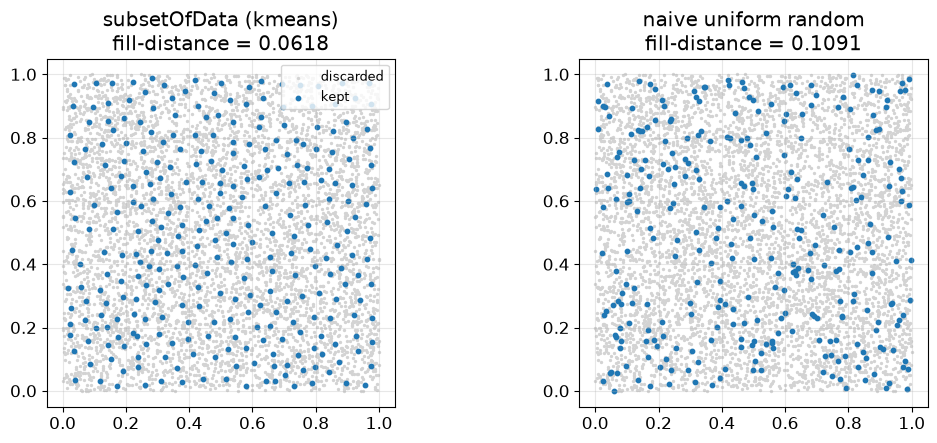

In [3]:
from scipy.spatial import cKDTree

n_sub = 300
t0 = time.perf_counter()
idx = lk.Kriging.subsetOfData(X_full, n_sub).ravel()
t_select = time.perf_counter() - t0
X_sub, y_sub = X_full[idx], y_full[idx]

# Fill distance: for every point in X_full, distance to nearest point in the subset
tree = cKDTree(X_sub)
dists, _ = tree.query(X_full, k=1)
fill_dist_kmeans = dists.max()

# Compare against a naive uniform-random subset of the same size
rand_idx = np.random.choice(n_full, size=n_sub, replace=False)
tree_rand = cKDTree(X_full[rand_idx])
dists_rand, _ = tree_rand.query(X_full, k=1)
fill_dist_random = dists_rand.max()

print(f'subsetOfData: {n_full} -> {len(idx)} points   selection time: {t_select*1000:.1f} ms')
print(f'fill-distance (kmeans subset): {fill_dist_kmeans:.4f}')
print(f'fill-distance (naive random subset, same size): {fill_dist_random:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, ix, title, fd in [(axes[0], idx, 'subsetOfData (kmeans)', fill_dist_kmeans),
                            (axes[1], rand_idx, 'naive uniform random', fill_dist_random)]:
    ax.scatter(X_full[:, 0], X_full[:, 1], s=2, c='lightgray', label='discarded')
    ax.scatter(X_full[ix, 0], X_full[ix, 1], s=10, c='C0', label='kept')
    ax.set_title(f'{title}\nfill-distance = {fd:.4f}')
    ax.set_aspect('equal')
axes[0].legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


## 3. Prediction accuracy: subset fit vs. the full-data fit

We fit an ordinary exact model on the $n_{\max}=300$-point subset, and
compare its held-out predictions against a model fit on a random,
same-size subset of $n_{\max}$ points — the fair baseline, since the whole
point of `subsetOfData` is doing *better* than picking rows at random.

In [4]:
theta0 = np.array([[0.3, 0.3]])

t0 = time.perf_counter()
k_sub = lk.Kriging(y_sub, X_sub, 'matern5_2', regmodel='constant',
                    objective='LL', optim='BFGS(1)', parameters={'theta': theta0})
t_sub = time.perf_counter() - t0
mean_sub, _ = k_sub.predict(Xt, False, False, False)[:2]
rmse_sub = rmse(mean_sub.ravel(), yt)

t0 = time.perf_counter()
k_rand = lk.Kriging(y_full[rand_idx], X_full[rand_idx], 'matern5_2', regmodel='constant',
                     objective='LL', optim='BFGS(1)', parameters={'theta': theta0})
t_rand = time.perf_counter() - t0
mean_rand, _ = k_rand.predict(Xt, False, False, False)[:2]
rmse_rand = rmse(mean_rand.ravel(), yt)

print(f'subsetOfData({n_sub}) fit:   {t_sub:5.2f} s   test RMSE = {rmse_sub:.4f}')
print(f'random subset({n_sub}) fit:  {t_rand:5.2f} s   test RMSE = {rmse_rand:.4f}')
print(f'\n({100*(rmse_rand-rmse_sub)/rmse_rand:+.1f}% RMSE change from using subsetOfData instead of random)')


subsetOfData(300) fit:    0.65 s   test RMSE = 0.0398
random subset(300) fit:   0.37 s   test RMSE = 0.0683

(+41.8% RMSE change from using subsetOfData instead of random)


## 4. How much data can you afford to keep? Accuracy vs. $n_{\max}$

We now compare, across a range of subset sizes, the accuracy each buys —
against the (expensive) full-data exact fit as the ceiling.

In [5]:
t0 = time.perf_counter()
k_full = lk.Kriging(y_full, X_full, 'matern5_2', regmodel='constant',
                     objective='LL', optim='BFGS(1)', parameters={'theta': theta0})
t_full = time.perf_counter() - t0
mean_full, _ = k_full.predict(Xt, False, False, False)[:2]
rmse_full = rmse(mean_full.ravel(), yt)
print(f'full-data ({n_full} pts) exact fit: {t_full:6.2f} s   test RMSE = {rmse_full:.4f}   (accuracy ceiling)')


full-data (6000 pts) exact fit: 412.48 s   test RMSE = 0.0026   (accuracy ceiling)


In [6]:
n_max_grid = [50, 100, 200, 300, 500, 800, 1200]
rmses_sub, times_sub = [], []
for nm in n_max_grid:
    idx_nm = lk.Kriging.subsetOfData(X_full, nm).ravel()
    t0 = time.perf_counter()
    k_nm = lk.Kriging(y_full[idx_nm], X_full[idx_nm], 'matern5_2', regmodel='constant',
                       objective='LL', optim='BFGS(1)', parameters={'theta': theta0})
    times_sub.append(time.perf_counter() - t0)
    mean_nm, _ = k_nm.predict(Xt, False, False, False)[:2]
    rmses_sub.append(rmse(mean_nm.ravel(), yt))
    print(f'n_max={nm:5d}   fit time={times_sub[-1]:6.2f} s   test RMSE={rmses_sub[-1]:.4f}')


n_max=   50   fit time=  0.01 s   test RMSE=0.0362


n_max=  100   fit time=  0.05 s   test RMSE=0.0326

n_max=  200   fit time=  0.14 s   test RMSE=0.0348


n_max=  300   fit time=  0.62 s   test RMSE=0.0398


n_max=  500   fit time=  1.11 s   test RMSE=0.0354
n_max=  800   fit time=  1.99 s   test RMSE=0.0387


n_max= 1200   fit time=  5.22 s   test RMSE=0.0412


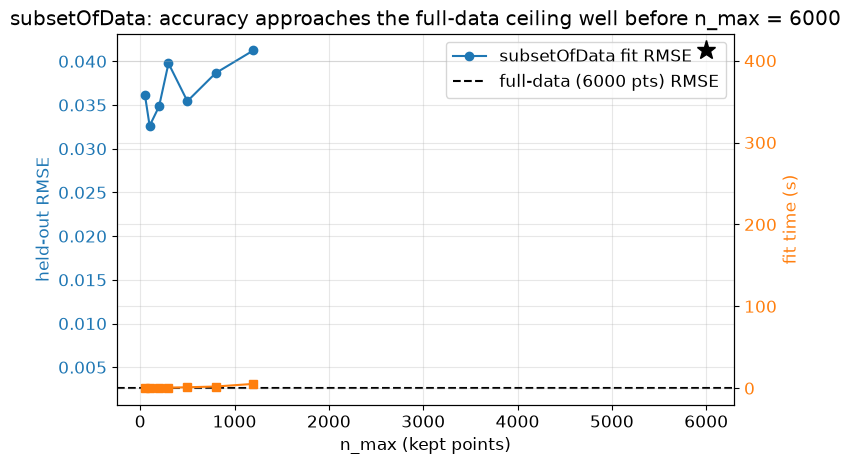

full-data fit time: 412.48 s  vs.  n_max=1200 subset fit time: 5.22 s  (79.0x)


In [7]:
fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax1.plot(n_max_grid, rmses_sub, 'o-', color='C0', label='subsetOfData fit RMSE')
ax1.axhline(rmse_full, color='k', ls='--', label=f'full-data ({n_full} pts) RMSE')
ax1.set_xlabel('n_max (kept points)')
ax1.set_ylabel('held-out RMSE', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.legend(loc='upper right')
ax2 = ax1.twinx()
ax2.plot(n_max_grid, times_sub, 's-', color='C1')
ax2.plot([n_full], [t_full], 'k*', markersize=14)
ax2.set_ylabel('fit time (s)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax1.set_title(f'subsetOfData: accuracy approaches the full-data ceiling well before n_max = {n_full}')
plt.tight_layout()
plt.show()

print(f'full-data fit time: {t_full:.2f} s  vs.  n_max={n_max_grid[-1]} subset fit time: {times_sub[-1]:.2f} s'
      f'  ({t_full/times_sub[-1]:.1f}x)')


## Practical guidance

- `subsetOfData` is the cheapest option here — an $O(n_{\max})$ k-means
  pass, negligible next to the $O(n_{\max}^3)$ fit that follows — but it's
  also the only one that **discards information**. Prefer
  `LLVecchia`/`LLNystrom`/`LLIterative`/`NestedKriging` if losing data
  isn't acceptable and `n` is large mainly because a genuinely global fit
  is needed.
- It composes with everything else: `subsetOfData` first, then fit however
  you like on the reduced design — including with `LLVecchia`/`LLNystrom`
  if $n_{\max}$ is itself still large.
- The `"kmeans"` centroid-snapping is a cheap *coverage* heuristic, not an
  optimal design (not a maximin/minimax design) — good enough as a pre-fit
  reduction when $X$ is already fixed, not a substitute for deliberate
  experimental design when the points themselves are still to be chosen.
- As §4 shows, accuracy typically saturates well before $n_{\max}$
  approaches the full $n$ — the marginal value of each additional kept
  point drops quickly once the subset already covers the domain
  reasonably well (this is domain/function-dependent: a function with
  sharper local features needs a denser subset to resolve them).

## References

- Lloyd, S. (1982). *Least squares quantization in PCM*. IEEE Transactions
  on Information Theory, 28(2), 129-137 — the k-means algorithm used for
  centroid selection.
- Seo, S., Wallat, M., Graepel, T., & Obermayer, K. (2000). *Gaussian
  process regression: Active data selection and test point rejection*.
  Proceedings of the International Joint Conference on Neural Networks —
  an early treatment of subsampling/active selection for scaling GP
  regression, in the same spirit as this pre-fit reduction (though
  libKriging's `subsetOfData` is a one-shot coverage heuristic, not an
  active/sequential criterion).

See also [SubsetOfData.md](SubsetOfData.md) for the full API reference,
and [Scalability.md](Scalability.md) for how it compares to `LLVecchia`,
`LLNystrom`, `LLIterative` and `NestedKriging`.